# A prediction range, then a check

**Yes: Bayesian uncertainty and a coverage test can work together.**
The model proposes a range for the next observation. Separate measurements
tell us how often that range actually works.

Let's use a machine that fills bottles, measured in millilitres.

## 1. Learn from 20 bottles

We do not know the machine's average fill. Before measuring, we put it near
100 mL, with a standard deviation of 5 mL to express our uncertainty.
We also assume individual bottles vary around that average with a standard
deviation of 2 mL. Both distributions are bell-shaped. These are our
**model assumptions**.

Bayesian updating combines this starting belief with the 20 measurements.
The updated belief is called the *posterior*. The calculation below gives an
average of **100.03 mL**, with remaining uncertainty of **0.45 mL**.


In [1]:
import math
from statistics import NormalDist
import numpy as np
import matplotlib.pyplot as plt

TEST_COUNT = 10_000       # choose before looking at test bottles
FAILURE_CHANCE = 0.05     # the validation bound may fail at most 5% of the time

train_rng, test_rng = [
    np.random.default_rng(s)
    for s in np.random.SeedSequence(20260919).spawn(2)
]
# A pretend machine, used only to make this example runnable.
training = train_rng.normal(100.5, 2, 20)

prior_mean, prior_sd, bottle_sd = 100, 5, 2
posterior_variance = 1 / (1/prior_sd**2 + len(training)/bottle_sd**2)
posterior_mean = posterior_variance * (
    prior_mean/prior_sd**2 + training.sum()/bottle_sd**2
)
print(f"Estimated average: {posterior_mean:.2f} mL")
print(f"Uncertainty about the average: {math.sqrt(posterior_variance):.2f} mL (SD)")


Estimated average: 100.03 mL
Uncertainty about the average: 0.45 mL (SD)


## 2. Predict the next bottle

A new bottle has its own variation, **plus** our remaining uncertainty about
the average. We add these two variances. This gives the *posterior predictive
distribution*: the model's distribution for the next observation.

Take its middle 99%. The result is about **94.75–105.31 mL**.
This is the UQ step: a prediction with a range, rather than just a best guess.
[Calculation reference](https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf).


In [2]:
predictive_sd = math.sqrt(bottle_sd**2 + posterior_variance)
multiplier = NormalDist().inv_cdf(0.995)  # 0.5% in each tail
low = posterior_mean - multiplier*predictive_sd
high = posterior_mean + multiplier*predictive_sd
print(f"The model's 99% prediction range: [{low:.2f}, {high:.2f}] mL")


The model's 99% prediction range: [94.75, 105.31] mL


**99% is what the model says. Now collect independent evidence.**

## 3. Check 10,000 new bottles

Freeze the range. Count how many new bottles fall inside it.
This fraction is called *coverage*.

Here we simulate fresh bottles from the pretend machine. For a real machine,
replace them with new physical measurements, not draws from the fitted model.


In [3]:
test = test_rng.normal(100.5, 2, TEST_COUNT)
inside = (test >= low) & (test <= high)
hits = int(inside.sum())
measured_coverage = hits / TEST_COUNT
print(f"Inside the range: {hits:,} of {TEST_COUNT:,}")
print(f"Measured coverage: {100*measured_coverage:.2f}%")


Inside the range: 9,909 of 10,000
Measured coverage: 99.09%


**9,909 out of 10,000** are inside: **99.09%**.
But another set of bottles would give a slightly different fraction.

## 4. Allow for that sampling error

Hoeffding gives a conservative allowance. For a 95% confidence statement,
subtract

$$
\sqrt{\frac{\log(1/0.05)}{2\times10{,}000}}
=0.01224
\quad\text{(about 1.224 percentage points).}
$$

That leaves **97.866%**. Rounding downward, we can report:

> **With 95% confidence, the fixed range covers at least 97.8% of bottles
> from this process.**


In [4]:
allowance = math.sqrt(math.log(1/FAILURE_CHANCE) / (2*TEST_COUNT))
lower_bound = max(0, measured_coverage - allowance)
reported_percent = math.floor(1000*lower_bound) / 10  # round downward
print(f"Sampling allowance: {100*allowance:.3f} percentage points")
print(f"With 95% confidence, coverage is at least {reported_percent:.1f}%.")


Sampling allowance: 1.224 percentage points
With 95% confidence, coverage is at least 97.8%.


The chance that this testing procedure overstates the true coverage is at
most 5%. This statement needs independent test bottles from the same process
as future bottles, and a range and test count fixed before checking them.
It **does not require the Bayesian model to be correct**.
[Bound reference](https://www.cs.rpi.edu/academics/courses/spring06/random/hoefding.pdf).

That is how the two pieces give rigor: **the model supplies the range;
fresh data and Hoeffding supply a defensible statement about its coverage.**
They validate this coverage property, not every assumption in the model.

Four times as many test bottles halves the allowance. More testing measures
coverage more precisely; improving or widening the range changes coverage.
If you change the range after checking it, use fresh data for the next check.

## See the range

The picture shows the first 100 test bottles. The calculation used all 10,000.


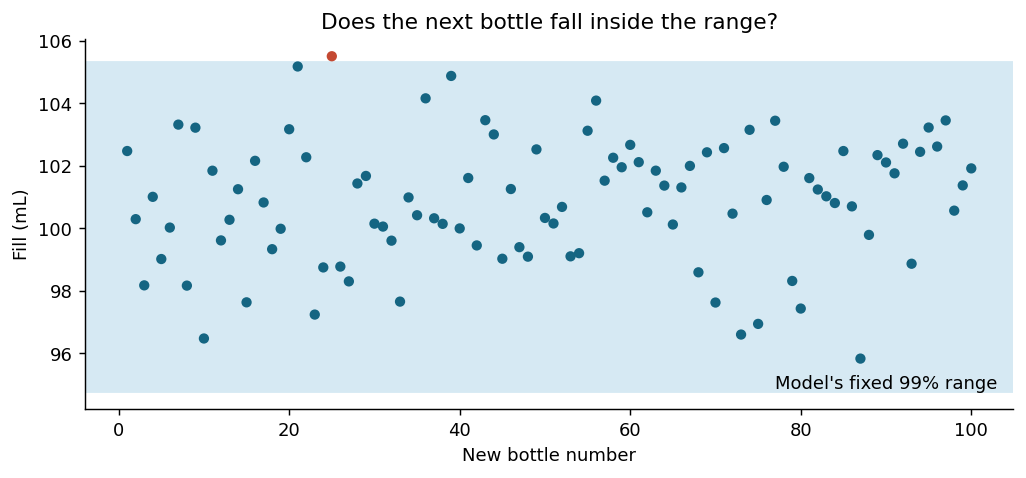

In [5]:
shown = 100
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.axhspan(low, high, color="#d6e9f3", label="Model's fixed 99% range")
ax.scatter(np.arange(1, shown+1), test[:shown], s=22,
           c=np.where(inside[:shown], "#156582", "#c44932"))
ax.set(xlabel="New bottle number", ylabel="Fill (mL)",
       title="Does the next bottle fall inside the range?")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()
